### EDA on coffee Dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("coffee.csv")

In [4]:
df.isnull().sum()


Unnamed: 0               0
Year                     0
Country                  0
Domestic Consumption    26
Exports                 26
Import Price            26
Export Price            26
Total Production        26
dtype: int64

In [5]:
df["Export Price"]=df["Export Price"].fillna(df["Export Price"].mean())
df["Import Price"]=df["Import Price"].fillna(df["Import Price"].mean())

In [6]:
df.isnull().sum()


Unnamed: 0               0
Year                     0
Country                  0
Domestic Consumption    26
Exports                 26
Import Price             0
Export Price             0
Total Production        26
dtype: int64

In [16]:
df.drop(columns="Unnamed: 0",inplace=True )

In [17]:
df = df.drop_duplicates()


In [18]:
#How many rows and columns are present in the dataset
df.shape

(509, 7)

In [19]:
# What are the names of all columns in the dataset
df.columns

Index(['Year', 'Country', 'Domestic Consumption', 'Exports', 'Import Price',
       'Export Price', 'Total Production'],
      dtype='object')

In [20]:
#What is the data type of each column
df.dtypes

Year                      int64
Country                  object
Domestic Consumption    float64
Exports                 float64
Import Price            float64
Export Price            float64
Total Production        float64
dtype: object

In [21]:
#first 5 rows of the dataset
df.head()

,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
0,2015,Argentina,13051.0,14887.0,2.6,2.700000,26614.0
1,2015,Argentina,13131.0,15055.0,2.6,3.000000,27019.0
2,2015,Argentina,13305.0,15075.0,2.7,3.125304,27232.0
3,2015,Brazil,21070.0,36806.0,1.9,1.900000,54721.0
4,2015,Canada,18063.0,21734.0,3.9,4.000000,38987.0


In [31]:
#last 5 rows of the datase
df.tail()

,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
515,2023,USA,28629.0,0.0,5.3,0.000000,0.0
516,2023,USA,28875.0,0.0,5.2,0.000000,0.0
517,2023,Vietnam,NaN,34342.0,2.9,3.200000,52222.0
518,2023,Vietnam,18557.0,34695.0,3.2,2.900000,52867.0
519,2023,Vietnam,18615.0,34840.0,3.0,3.125304,52639.0


In [27]:
#Which columns contain missing values
df.isnull().sum()[df.isnull().sum()>0]

Domestic Consumption    26
Exports                 26
Total Production        26
dtype: int64

In [29]:
# unique countries are present in the dataset
df["Country"].nunique()

20

In [35]:
#How many records are available for each year
df["Year"].value_counts().sort_index()

Year
2015    71
2016    57
2017    58
2018    43
2019    55
2020    57
2021    60
2022    56
2023    52
Name: count, dtype: int64

In [38]:
#How many records are available for each country
df["Country"].value_counts()

Country
France          30
Argentina       29
South Africa    29
Chile           28
Italy           28
Colombia        28
Indonesia       27
Germany         27
Mexico          27
China           26
India           26
Canada          24
USA             24
Brazil          23
Ethiopia        23
Turkey          23
Vietnam         23
Kenya           22
Thailand        22
Peru            20
Name: count, dtype: int64

In [42]:
#minimum, maximum, and average of total production
min=df["Total Production"].min()

max=df["Total Production"].max()

total=df["Total Production"].mean()
min,max,total

(0.0, 264565.0, np.float64(46863.58799171843))

In [48]:
#Country with Highest Single Production
df.loc[df["Total Production"].idxmax()]

Year                        2023
Country                    China
Domestic Consumption    159839.0
Exports                 108888.0
Import Price                 3.9
Export Price                 3.8
Total Production        264565.0
Name: 480, dtype: object

In [43]:
#Rows Where Production is Missing or Zero
df[(df["Total Production"].isnull()) | (df["Total Production"] == 0)]

,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
14,2015,China,119776.0,85031.0,3.0,3.5,NaN
27,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
29,2015,Germany,8887.0,11273.0,3.4,3.6,0.0
30,2015,Germany,8396.0,10988.0,3.0,3.7,0.0
31,2015,Germany,8197.0,10984.0,3.5,3.4,NaN
...,...,...,...,...,...,...,...
512,2023,USA,28601.0,0.0,5.5,0.0,0.0
513,2023,USA,28632.0,0.0,5.1,0.0,0.0
514,2023,USA,29342.0,0.0,5.5,0.0,0.0
515,2023,USA,28629.0,0.0,5.3,0.0,0.0


In [49]:
#Average Import Price
df["Import Price"].mean()

np.float64(3.1563230276083134)

In [87]:
#Total Coffee Production Per Year
year_wise_prod=df.groupby('Year')['Total Production'].sum()


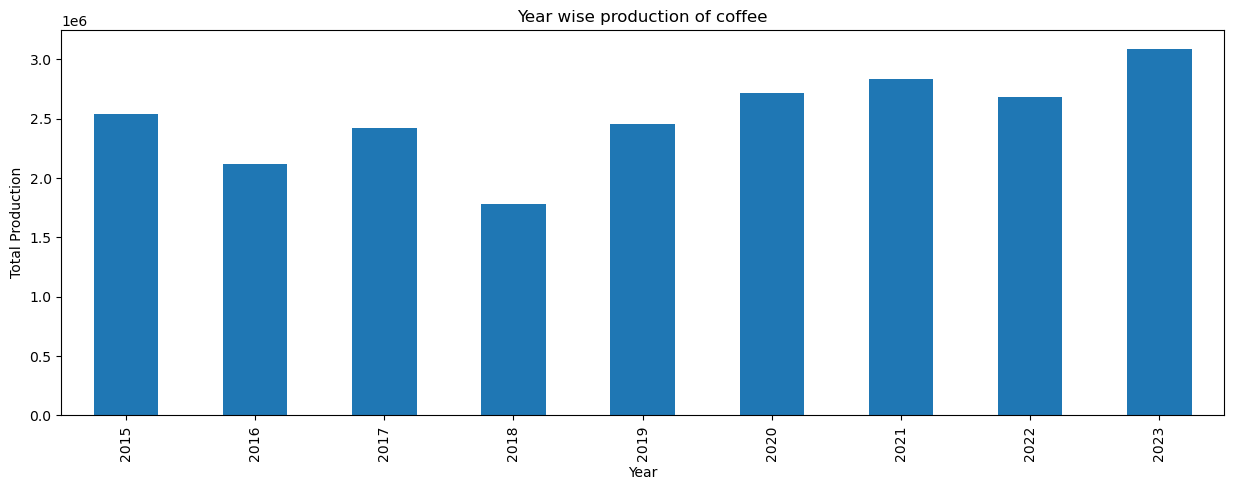

In [88]:
plt.figure(figsize=(15,5))
year_wise_prod.plot(kind='bar')
plt.title("Year wise production of coffee")
plt.xlabel("Year")
plt.ylabel("Total Production")


plt.show()

In [59]:
#Top 5 Countries Based on Total Production
top5=df.groupby("Country")["Total Production"].sum().sort_values(ascending=False)
ans=top5[:5]
ans

Country
China        5682192.0
India        1902283.0
France       1774254.0
Mexico       1766558.0
Indonesia    1582361.0
Name: Total Production, dtype: float64

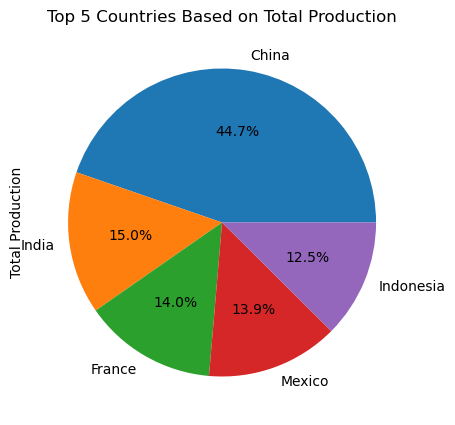

In [90]:
plt.figure(figsize=(15,5))
ans.plot(kind='pie',autopct='%0.1f%%' )  # -->shows percentage values
plt.title("Top 5 Countries Based on Total Production")
plt.show()


In [60]:
#Country with Highest Average Export Price
df.groupby("Country")["Export Price"].mean().sort_values(ascending=False).head(1)

Country
Canada    4.186496
Name: Export Price, dtype: float64

In [68]:
#Does domestic consumption exceed total production for any country
df[df['Domestic Consumption'] > df['Total Production']].head()

,Year,Country,Domestic Consumption,Exports,Import Price,Export Price,Total Production
27,2015,Germany,8514.0,11030.0,3.2,3.5,0.0
29,2015,Germany,8887.0,11273.0,3.4,3.6,0.0
30,2015,Germany,8396.0,10988.0,3.0,3.7,0.0
32,2015,Germany,8121.0,11043.0,3.1,3.7,0.0
63,2015,USA,24902.0,NaN,4.6,0.0,0.0


In [ ]:
#country shows the highest growth in total production over the years
growth = df.groupby(['Country','Year'])['Total Production'].mean().reset_index()
pivot = growth.pivot(index='Year', columns='Country', values='Total Production')
growth_rate = pivot.iloc[-1] - pivot.iloc[0]
top5=growth_rate.sort_values(ascending=False).head(5)

#country aur year ko ek sath leke uske side mai total production  k value aagya
#uske baad pivot use krke column structure change kr liye
#phir first aur last ko minus krrdiye

top5

Country
China        64151.6
India        18423.0
Mexico       14063.5
Brazil       12236.6
Indonesia    10609.0
dtype: float64

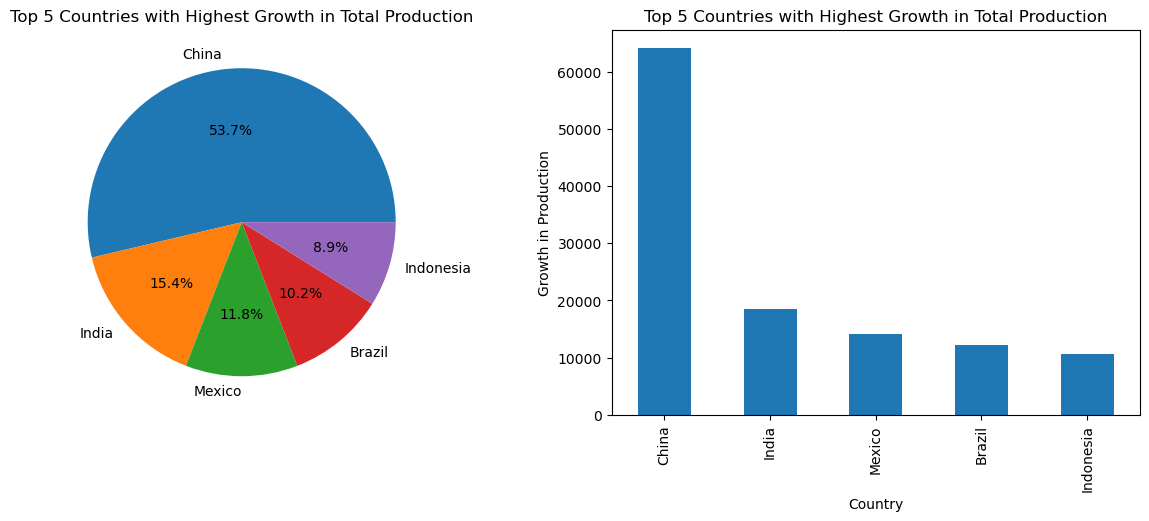

In [84]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
top5.plot(kind='pie',autopct='%0.1f%%' )  # -->shows percentage values
plt.title("Top 5 Countries with Highest Growth in Total Production")


plt.subplot(1,2,2)
top5.plot(kind='bar')
plt.title("Top 5 Countries with Highest Growth in Total Production")
plt.xlabel("Country")
plt.ylabel("Growth in Production")


plt.show()

In [66]:
df[['Export Price','Total Production']].corr()


,Export Price,Total Production
Export Price,1.000000,0.339369
Total Production,0.339369,1.000000


### Conclusion
There are 20 unique countries which produce coffee in which china produce maximum


Along with china India,France,Mexico and Indonesia is the top producer


Canada has highest average export price

Some countries has 0 production but it has Domestic consumption it mean they are relying on imports

China shows highest growth rate from 2015 to 2023